Scenario
You are an analyst at an online retail company. You have data on:

Monthly sales for two product categories (Electronics, Clothing).

Customer satisfaction scores from three regions (North, South, West).

Marketing budget allocation by channel.

Your task: build a 2‑row × 2‑column dashboard using subplots(2, 2) that communicates all three datasets clearly.

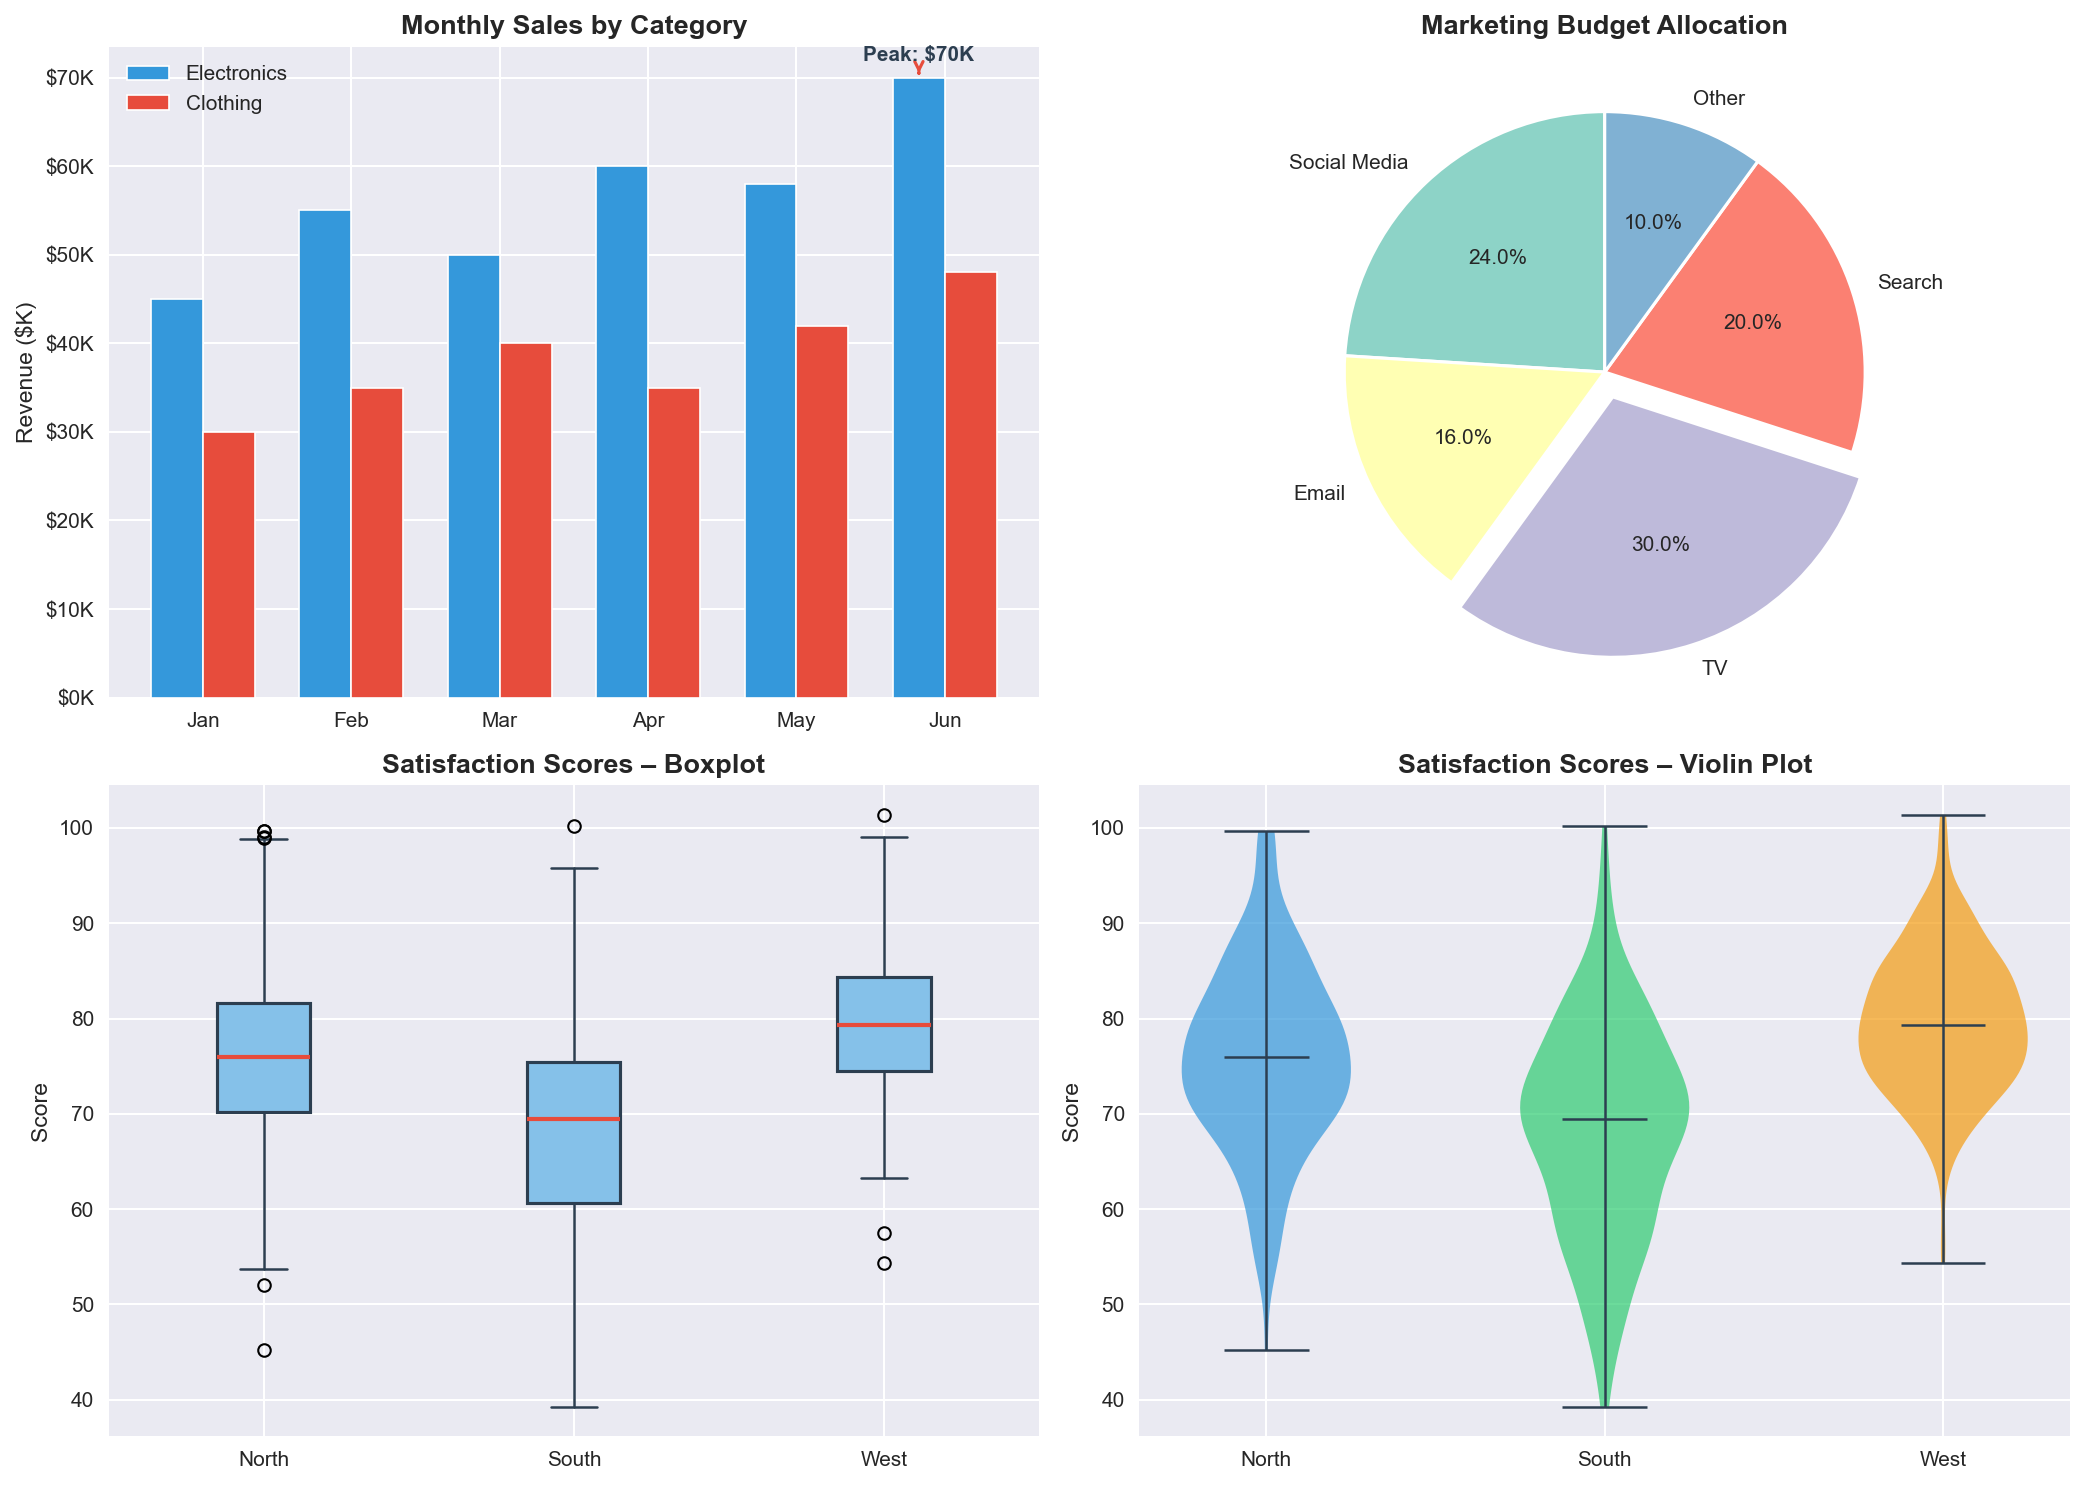

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ---------- GIVEN DATA ----------
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
electronics = [45, 55, 50, 60, 58, 70]      # $K
clothing    = [30, 35, 40, 35, 42, 48]

np.random.seed(10)
north = np.random.normal(75, 10, 200)
south = np.random.normal(68, 12, 200)
west  = np.random.normal(80, 8, 200)
satisfaction_data = [north, south, west]

channels = ['Social Media', 'Email', 'TV', 'Search', 'Other']
budget   = [12000, 8000, 15000, 10000, 5000]

# ---------- GLOBAL STYLE ----------
plt.style.use('seaborn-v0_8')

# ---------- 2x2 DASHBOARD ----------
fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=150)

# ========== PANEL A : Grouped Bar Chart ==========
ax_a = axes[0, 0]
x_pos = np.arange(len(months))
width = 0.35
bars1 = ax_a.bar(x_pos - width/2, electronics, width, label='Electronics',
                 color='#3498DB', edgecolor='white', linewidth=0.8)
bars2 = ax_a.bar(x_pos + width/2, clothing, width, label='Clothing',
                 color='#E74C3C', edgecolor='white', linewidth=0.8)

# Annotate the highest bar (Electronics in June → index 5, height 70)
peak_bar = bars1[5]
ax_a.annotate("Peak: $70K",
              xy=(peak_bar.get_x() + peak_bar.get_width()/2, peak_bar.get_height()),
              xytext=(0, 8), textcoords='offset points',
              ha='center', fontsize=10, fontweight='bold', color='#2C3E50',
              arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=1.5))

# Y-axis formatting: show as $xxK
ax_a.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'${x:.0f}K'))

ax_a.set_xticks(x_pos)
ax_a.set_xticklabels(months)
ax_a.set_title("Monthly Sales by Category", fontweight='bold', fontsize=13)
ax_a.set_ylabel("Revenue ($K)")
ax_a.legend()
ax_a.spines['top'].set_visible(False)
ax_a.spines['right'].set_visible(False)

# ========== PANEL B : Pie Chart ==========
ax_b = axes[0, 1]
# Find the largest slice (TV) and explode it
max_idx = budget.index(max(budget))
explode = [0.1 if i == max_idx else 0 for i in range(len(budget))]

ax_b.pie(budget, labels=channels, autopct='%1.1f%%',
         startangle=90, explode=explode,
         colors=plt.cm.Set3.colors[:len(channels)],
         wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax_b.set_title("Marketing Budget Allocation", fontweight='bold', fontsize=13)

# ========== PANEL C : Boxplot ==========
ax_c = axes[1, 0]
bp = ax_c.boxplot(satisfaction_data, patch_artist=True,
                  tick_labels=['North', 'South', 'West'],
                  boxprops=dict(facecolor='#85C1E9', color='#2C3E50', linewidth=1.5),
                  medianprops=dict(color='#E74C3C', linewidth=2),
                  whiskerprops=dict(color='#2C3E50', linewidth=1.2),
                  capprops=dict(color='#2C3E50', linewidth=1.2))
ax_c.set_title("Satisfaction Scores – Boxplot", fontweight='bold', fontsize=13)
ax_c.set_ylabel("Score")
ax_c.spines['top'].set_visible(False)
ax_c.spines['right'].set_visible(False)

# ========== PANEL D : Violin Plot ==========
ax_d = axes[1, 1]
violins = ax_d.violinplot(satisfaction_data, showmedians=True, showextrema=True)
body_colors = ['#3498DB', '#2ECC71', '#F39C12']
for i, body in enumerate(violins['bodies']):
    body.set_facecolor(body_colors[i])
    body.set_alpha(0.7)
for part in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
    violins[part].set_edgecolor('#2C3E50')
    violins[part].set_linewidth(1.2)

ax_d.set_title("Satisfaction Scores – Violin Plot", fontweight='bold', fontsize=13)
ax_d.set_ylabel("Score")
ax_d.set_xticks([1, 2, 3])
ax_d.set_xticklabels(['North', 'South', 'West'])
ax_d.spines['top'].set_visible(False)
ax_d.spines['right'].set_visible(False)

# ---------- FINAL LAYOUT ----------
plt.tight_layout()
plt.show()